# Reinforcement Learning Tutorial 2: The RL Detective's Guide

**Course:** Reinforcement Learning WBAI061-05 (2025/2026)

**Lecturer:** Rafael F. Cunha, University of Groningen

In [1]:
# Core libraries
import copy
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm 
import traceback
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors
# from tqdm.notebook import tqdm # For progress bars

# Plotting style
sns.set(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 🔧 Helper Functions (click the triangle to expand/collapse)

In [2]:
# We will add helper functions here as we need them throughout the tutorial.
# This keeps the main narrative clean and focused on the core concepts.

def plot_gridworld_trajectory(env_map, trajectory, ax=None):
    """Visualize a trajectory on the FrozenLake map."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    
    rows, cols = env_map.shape
    ax.imshow(np.zeros((rows, cols)), cmap="Blues", alpha=0) # transparent background
    
    # Draw grid lines
    ax.set_xticks(np.arange(cols + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(rows + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
    ax.tick_params(which="minor", size=0)
    ax.tick_params(which="major", bottom=False, left=False, labelbottom=False, labelleft=False)

    # Color states
    for r in range(rows):
        for c in range(cols):
            char = env_map[r, c]
            text_color = "black"
            if char == b'S':
                color, text = "skyblue", "Start"
            elif char == b'F':
                color, text = "whitesmoke", "Ice"
            elif char == b'H':
                color, text = "gray", "Hole"
            elif char == b'G':
                color, text = "gold", "Goal"
            else:
                color, text = "white", ""
            
            rect = plt.Rectangle([c - 0.5, r - 0.5], 1, 1, facecolor=color, edgecolor='black')
            ax.add_patch(rect)
            ax.text(c, r, text, ha='center', va='center', color=text_color, weight='bold')

    # Draw trajectory
    if trajectory:
        states = np.array([env.unwrapped.s // cols, env.unwrapped.s % cols] for env in trajectory)
        ax.plot(states[:, 1], states[:, 0], 'r-o', markersize=8, linewidth=3, label="Agent Path")
        # Mark the start of the path
        ax.plot(states[0, 1], states[0, 0], 'go', markersize=12, label="Episode Start")

    ax.set_title("Agent Trajectory on FrozenLake")
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True, ncol=2)
    plt.show()

def plot_value_heatmap(V, env, title="Value Function Heatmap", ax=None):
    """
    Visualizes a value function V as a heatmap overlaid on the environment grid.
    """

    n_states = env.observation_space.n
    grid_size = int(np.sqrt(n_states))
    if grid_size * grid_size != n_states:
        raise ValueError("Can only plot for square grid worlds.")
        
    value_grid = V.reshape((grid_size, grid_size))

    # If no axis is provided, create a new figure as before
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    # plt.figure(figsize=(8, 8))
    sns.heatmap(value_grid, annot=True, fmt=".2f", cmap="viridis", cbar=False, linewidths=.5, ax=ax)
    

    ax.set_title(title, fontsize=16)
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

    if ax is None:
        plt.title(title, fontsize=16)
        plt.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
        plt.show()

# --- Replace the old helper function with this correct version ---
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors

def plot_q_function(Q, env, title="Action-Value Function (Q)", ax=None):
    """
    Visualizes a Q-function as a grid of triangles, where each triangle
    represents an action and its color/value corresponds to the Q-value.
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    grid_size = int(np.sqrt(n_states))
    if grid_size * grid_size != n_states:
        raise ValueError("Can only plot for square grid worlds.")

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    ax.set_xticks(np.arange(grid_size + 1) - 0.5)
    ax.set_yticks(np.arange(grid_size + 1) - 0.5)
    ax.grid(color='black', linestyle='-', linewidth=2)
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

    norm = mcolors.Normalize(vmin=Q.min(), vmax=Q.max())
    cmap = plt.cm.viridis

    for s in range(n_states):
        r, c = s // grid_size, s % grid_size
        
        # --- THE FIX IS IN THIS SECTION ---
        # Define the four corners and the center of the cell
        top_left = (c, r)
        top_right = (c + 1, r)
        bottom_left = (c, r + 1)
        bottom_right = (c + 1, r + 1)
        center = (c + 0.5, r + 0.5)
        
        # Define vertices for the 4 action-triangles
        # Each triangle is made of two corners and the center
        # 0:Left, 1:Down, 2:Right, 3:Up
        vertices = {
            3: [top_left, center, top_right],        # Up
            1: [bottom_left, center, bottom_right],  # Down
            0: [top_left, center, bottom_left],      # Left
            2: [top_right, center, bottom_right]     # Right
        }
        
        # Check if it's a terminal state to color the whole cell
        if s in get_terminal_states(env):
            char = env.unwrapped.desc[r, c].decode('utf-8')
            color = 'gray'
            if char == 'G': color = 'lightgreen'
            if char == 'H': color = 'lightcoral'
            ax.add_patch(Polygon([top_left, top_right, bottom_right, bottom_left], facecolor=color))
            # Also add the value for completeness
            ax.text(center[0], center[1], f"{np.mean(Q[s,:]):.2f}", ha='center', va='center', fontsize=12, color='black')
            continue

        for a in range(n_actions):
            q_value = Q[s, a]
            color = cmap(norm(q_value))
            
            poly = Polygon(vertices[a], facecolor=color, edgecolor='white')
            ax.add_patch(poly)
            
            # Position text inside triangles
            if a == 3: text_pos = (center[0], center[1] - 0.25) # Up
            elif a == 1: text_pos = (center[0], center[1] + 0.25) # Down
            elif a == 0: text_pos = (center[0] - 0.25, center[1]) # Left
            else: text_pos = (center[0] + 0.25, center[1]) # Right
            
            ax.text(text_pos[0], text_pos[1], f"{q_value:.2f}", ha='center', va='center', fontsize=9, color='white' if norm(q_value) < 0.5 else 'black')

    ax.set_title(title, fontsize=16)
    ax.set_xlim(0, grid_size)
    ax.set_ylim(grid_size, 0)

def analytical_policy_evaluation(env, policy_matrix, gamma):
    """
    Performs a full analytical policy evaluation using the Bellman equation.
    """
    P = get_transition_matrix(env)
    R = get_reward_matrix(env)
    n_states, n_actions, _ = P.shape

    P_pi, R_pi = build_policy_model(P, R, policy_matrix)
    term_states = get_terminal_states(env)
    V_pi = solve_bellman_equation(P_pi, R_pi, gamma, term_states)
    
    return V_pi

def convert_deterministic_policy_to_matrix(policy_object, n_states, n_actions):
    """
    Converts a deterministic policy object into its [S x A] matrix representation.

    Args:
        policy_object: An object with a .choose_action(state) method.
        n_states (int): The number of states.
        n_actions (int): The number of actions.

    Returns:
        np.ndarray: The [S x A] policy matrix.
    """
    policy_matrix = np.zeros((n_states, n_actions))
    for s in range(n_states):
        # Get the single action the policy chooses from this state
        action = policy_object.choose_action(s)
        # Set the probability of that action to 1.0
        policy_matrix[s, action] = 1.0
    return policy_matrix

# --- Environment Setup (Provided for you) ---
def get_transition_matrix(env):
    """
    Extracts the full P(s'|s,a) transition matrix from the environment's
    base dynamics. Returns a clean [S x A x S] NumPy array.
    """
    # This is correct as is, because it reflects the true underlying dynamics.
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    P = np.zeros((n_states, n_actions, n_states))
    
    for state, transitions in env.unwrapped.P.items():
        for action, outcomes in transitions.items():
            for prob, next_state, _, _ in outcomes:
                P[state, action, next_state] += prob
    return P

def get_reward_matrix(env):
    """
    Reconstructs the R(s,a) reward matrix by probing the specific
    environment instance provided. Returns a clean [S x A] NumPy array.
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    R = np.zeros((n_states, n_actions))

    # THE FIX: Create a deep copy to probe, ensuring we don't alter the
    # original environment's state but still test the correct object.
    probe_env = copy.deepcopy(env)

    _, _ = probe_env.reset()
    for state in range(n_states):
        for action in range(n_actions):
            # Set the state of our probe environment
            probe_env.unwrapped.s = state
            # Take a step to get the reward from that (s,a) pair
            _, reward, _, _, _ = probe_env.step(action)
            R[state, action] = reward
    return R

def get_terminal_states(env):
    """
    Finds all terminal states in the environment from the map.
    Returns a list of integer state IDs.
    """
    terminal_states = []
    # env.unwrapped.desc is the map, .flatten() makes it a 1D array
    grid_map = env.unwrapped.desc.flatten()
    for s, char in enumerate(grid_map):
        if char in b'HG': # b'H' is Hole, b'G' is Goal
            terminal_states.append(s)
    return terminal_states


class ContinuingTaskWrapper(gym.Wrapper):
    """A wrapper to make an episodic environment behave like a continuing one."""
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        # We ignore the 'terminated' signal from the base environment.
        return obs, reward, False, False, info

# class NonMarkovianWrapper(gym.ObservationWrapper):
#     """A wrapper to make the environment non-Markovian by aliasing states."""
#     def __init__(self, env):
#         super().__init__(env)
#         # We make state 5 and state 10 both appear as observation 5 to the agent.
#         self.alias_map = {8: 7}

#     def observation(self, obs):
#         return self.alias_map.get(obs, obs)

class NonMarkovianWrapper(gym.Wrapper):
    """
    A wrapper that makes the environment non-Markovian by aliasing states.
    It overrides step() and reset() to ensure the agent only ever sees
    the (potentially false) observation.
    """
    def __init__(self, env):
        super().__init__(env)
        # The alias map that causes the "lie"
        self.alias_map = {8: 7} 

    def _get_observation(self, true_state):
        """Applies the alias map to the true state."""
        return self.alias_map.get(true_state, true_state)

    def reset(self, **kwargs):
        # 1. Reset the underlying environment to get the TRUE initial state
        true_initial_state, info = self.env.reset(**kwargs)
        # 2. Return the (potentially false) OBSERVATION to the agent
        return self._get_observation(true_initial_state), info

    def step(self, action):
        # 1. Take a step in the underlying environment with the TRUE state
        true_next_state, reward, terminated, truncated, info = self.env.step(action)
        # 2. Return the (potentially false) OBSERVATION to the agent
        return self._get_observation(true_next_state), reward, terminated, truncated, info

class CustomRewardWrapper(gym.RewardWrapper):
    """
    A wrapper to assign specific, high-contrast rewards based on the state the agent lands in.
    """
    def __init__(self, env):
        super().__init__(env)
        # We need access to the map to know if a state is a hole
        self.map = env.unwrapped.desc.flatten()
        
    def reward(self, reward):
        # The 'reward' passed in is the default (1.0 for goal, 0 otherwise)
        # We will ignore it and create our own reward signal.
        
        # Get the character for the agent's current state
        current_state_char = self.map[self.env.unwrapped.s]
        
        if current_state_char == b'G':
            return 10.0
        elif current_state_char == b'H':
            return -10.0
        else: # 'S' or 'F'
            return -0.1

class DenseRewardWrapper(gym.RewardWrapper):
    """A wrapper to add a small negative reward to each step."""
    def __init__(self, env, step_reward=-0.01):
        super().__init__(env)
        self.step_reward = step_reward

    def reward(self, reward):
        # The original reward is 1.0 for the goal, 0 otherwise.
        # We add our step penalty to it.
        return reward + self.step_reward

# We add a RandomStartWrapper to enable our future mystery.
class RandomStartWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Find all squares that are not holes or goals
        self.free_squares = [
            s for s in range(env.observation_space.n)
            if env.unwrapped.desc.flatten()[s] not in (b'H', b'G')
        ]
    def reset(self, **kwargs):
        # This is the standard way to handle seeding in Gymnasium wrappers.
        # It ensures that our wrapper's own RNG is seeded correctly.
        super().reset(**kwargs)
        
        # THE FIX:
        # 1. Pick a random start state using our own seeded RNG.
        new_start_state = self.np_random.choice(self.free_squares)
        
        # 2. Manually set the internal state of the base environment.
        self.env.unwrapped.s = new_start_state
        
        # 3. Return the correct tuple, WITHOUT calling the underlying env.reset().
        #    The observation is our new state, and info is an empty dictionary.
        return new_start_state, {}

def create_mystery_environment(
    is_slippery=True,
    is_continuing=True,
    is_non_markovian=True,
    has_random_start=True,
    has_dense_rewards=True,
    render_mode=None
):
    """
    Factory function to build the client's environment with specific mysteries enabled/disabled.
    The defaults create the full "black box" for the first investigation.
    """
    # This custom map adds more features to make the effects of randomness more visible.
    # custom_map = [
    #     "SFFH",
    #     "FHFF",
    #     "HFFH",
    #     "GFFH"
    # ]
    custom_map = [
        "SFFH",
        "FFFF",
        "FFFH",
        "GFFF"
    ]
    # Create the base environment, controlling for slipperiness
    base_env = gym.make(
        'FrozenLake-v1', 
        is_slippery=is_slippery, 
        desc=custom_map, 
        render_mode=render_mode
        )
    
    env = base_env # Start with the base env
    
    # Conditionally apply each wrapper based on the flags
    if has_random_start:
        env = RandomStartWrapper(env)
    if is_non_markovian:
        env = NonMarkovianWrapper(env)
    if has_dense_rewards:
        env = CustomRewardWrapper(env)
    if is_continuing:
        env = ContinuingTaskWrapper(env)
        
    return env

# The RL Detective's Guide to Unmasking the MDP

Welcome, detective. Your mission is to investigate a new, mysterious "black box" environment. We have an agent, but we know very little about the world it lives in. Our client has one, seemingly simple question for you to answer:

**"What is the return of this environment?"**

This lab is a series of "mysteries." Each one will reveal a core concept of Reinforcement Learning and show you why a deep understanding of the **Markov Decision Process (MDP)** is crucial before you can even begin to train an agent.

## Your Mission Briefing

Your mission is to develop the skills needed to solve complex reinforcement learning cases. 

By the end of this investigation, you will be able to:

- **Learn to extract a stable, meaningful signal from simulations**.
- **Pinpoint the Sources of Unpredictability in a MDP**. 
- **Learn to interpret "value maps"**. 
- **Build the Final Case:** Formulate a complete, and precise answer to the client's initial, seemingly simple question.

# Case 1: The mystery of the Unstable Return

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Case File
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Let's begin our investigation. Our first task is to gather preliminary evidence to answer the client's question: **"What is the return of this environment?"**

**The Scene of the Crime**  
Our client has provided us with a "black box" grid-world system. They report that it is a **modified version of the well-known `FrozenLake` testbed**, but its internal rules are unknown and may have been changed.

The case file includes a diagram of a *possible* layout:

<br>
<center>
<img src="https://gymnasium.farama.org/_images/frozen_lake.gif" alt="A possible FrozenLake layout" width="250">
</center>
<br>

**Important Note:** The client mentioned a "cost of living" in this world. Unlike the standard `FrozenLake`, every action taken incurs a small negative reward, encouraging efficiency.

**The Initial Experiment**  
To find the "return," the most direct approach is to run a simulation to gather empirical data. This process, often called a **Monte Carlo rollout**, involves letting an agent interact with the environment for a series of steps and recording what happens.

For now, we will define the "Return" in the simplest way possible: as the **total sum of all rewards** collected during a rollout.

Let's set up the code to run our first rollout.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap:break-word;">

Imagine you are writing the code for the simulation loop. At each step, the agent is in a certain state. It needs to pass an action to the environment's `step` function. **How does the agent decide which action to take?**

<details>
  <summary style="cursor: pointer; font-weight: bold;">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

Does it move Up, Down, Left, or Right? Who decides? The environment doesn't provide this rule. The original question, "What is the return of this environment?", seems to be missing a critical piece of information. What is that missing piece?

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap:break-word;">



<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click here.</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

You've discovered the first critical clue: the question is incomplete because it doesn't specify the **agent's behavior**. The set of rules an agent uses to select actions is called its **policy (π)**.

The return an agent gets depends entirely on the policy it follows. A more precise question is, "What is the return of this environment *when following a specific policy*?"

Since we know nothing about this black box, any specific strategy (like "always go right") would be biased. The only unbiased way to begin our investigation is with a **Random Policy**: at every step, the agent will choose an action uniformly at random.

Now that we have a policy, we can finally write the code for our first experiment.

  </div>
</details>


  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 Case File Details: State and Action IDs
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Before we run the simulation, let's get familiar with our investigative tools.


The environment communicates in numbers. To understand its reports, you need to know what they mean. 

For a 4x4 grid, the states are numbered 0 to 15, and the actions are numbered 0 to 3.

<pre>
STATE IDs          ACTION IDs
+---+---+---+---+    0: Left
| 0 | 1 | 2 | 3 |    1: Down
+---+---+---+---+    2: Right
| 4 | 5 | 6 | 7 |    3: Up
+---+---+---+---+
| 8 | 9 | 10| 11|
+---+---+---+---+
| 12| 13| 14| 15|
+---+---+---+---+
</pre>


  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #F2B824;border-radius:10px;overflow:hidden;">

  <div style="background:#F2B824;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    💡 The Detective's Toolkit: Interacting with the Environment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Before we run the simulation, we need to understand our primary investigative tools, which are the functions for interacting with any Gymnasium environment.

1.  **`env.reset()`**
    - **Purpose:** Resets the environment to a starting state and prepares it for a new rollout.
    - **Returns:** The initial `observation` (the agent's starting state) and some diagnostic `info`.
    - **Usage:** `observation, info = env.reset()`

2.  **`env.step(action)`**
    - **Purpose:** This is the engine of the simulation. You pass it the agent's chosen `action`. The environment executes the action and transitions to a new state.
    - **Returns:** A tuple with five crucial pieces of information:
        - `observation`: The agent's new state.
        - `reward`: The reward received for taking that action.
        - `terminated`: A boolean (`True`/`False`) that is `True` if the episode ended because a terminal state (like a goal or hole) was reached.
        - `truncated`: A boolean that is `True` if the episode ended for another reason (like a time limit).
        - `info`: A dictionary with extra diagnostic information.
    - **Usage:** `observation, reward, terminated, truncated, info = env.step(chosen_action)`

With these two tools, we have everything we need to conduct our experiment.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>
  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Let's run our first simulation. We will:
1.  Instantiate our client's complex "black box" environment.
2.  Implement the **Random Policy** inside a simulation loop.
3.  Run the simulation for `T=100` steps. 
4.  We will plot the **cumulative sum of rewards at each step**. This visualization will show us how the total Return accumulates over the course of the rollout.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">
  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 1
  </div>
  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Complete the code below to run a single Monte Carlo rollout.

Your task is to **fill in the missing lines**:
1.  Implement the agent-environment interaction loop (choose an action, step the environment, store the reward).
2.  After the loop, compute the **cumulative sum of rewards** (`cumulative_returns`) for plotting.

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- The environment object has a component called `action_space` that knows all the possible actions. You can ask it to give you a valid random action by calling its `sample()` method:
<br>
`random_action = env.action_space.sample()`

- To calculate the cumulative sum of rewards for plotting, `np.cumsum()` is a very helpful function.
   
  </div>
</details>

  </div>
</div>

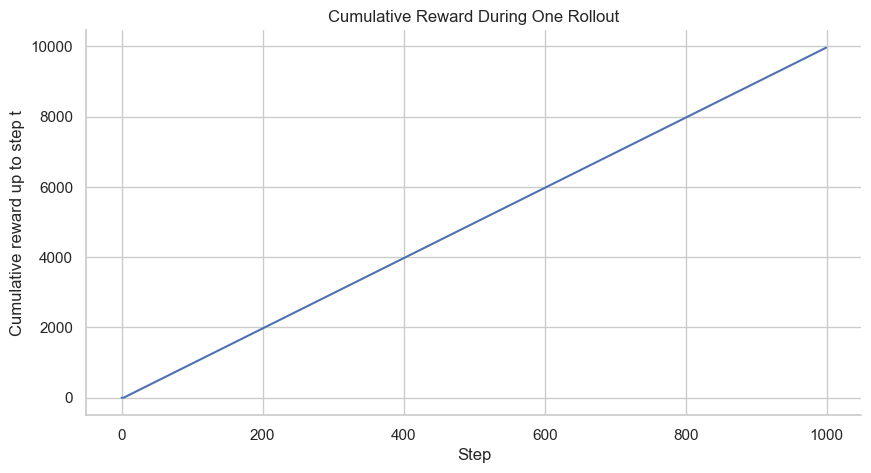

In [16]:
# The client's black box environment is created for you.
env = create_mystery_environment()

# --- Simulation Parameters ---
T = 1000
seed = 123
# --- Simulation ---
rewards = []

observation, info = env.reset(seed=seed)

for step in range(T):
    # --- YOUR CODE HERE ---
    
    # 1. Choose a random action.
    random_action = env.action_space.sample()

    # 2. Take the action in the environment.
    observation, reward, terminated, truncated, info = env.step(random_action)

    # 3. Store the received reward.
    rewards.append(reward)

    # --- END YOUR CODE ---
    
    if terminated or truncated:
        print(f"Episode ended unexpectedly at step {step}!")
        break

# --- YOUR CODE HERE ---

# 4. After the loop, calculate the cumulative return at each step.
# Hint: np.cumsum() is useful here.
cumulative_returns = np.cumsum(rewards)

# --- END YOUR CODE ---


# --- Visualize the results of the experiment ---
plt.figure(figsize=(10, 5))
plt.plot(cumulative_returns)
plt.title("Cumulative Reward During One Rollout")
plt.xlabel("Step")
plt.ylabel("Cumulative reward up to step t")
plt.grid(True)
plt.show()

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items_center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Analyze the plot you just generated. This is your first key piece of evidence.

1.  The plot shows a nearly straight line sloping steadily downwards. What does this tell you about the rewards the agent is receiving at each step?
2.  What do you think this plot would look like if we ran the simulation for 1,000 steps? What if we ran it forever? Where would the line go?
3.  This presents a problem. The total "Return" (our simple sum) just keeps getting more negative and doesn't seem to converge to a stable, useful value. What fundamental property of the environment do you suspect is causing this?

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: The Case of the Infinite Return
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Your analysis of the evidence is correct. The Return just keeps getting more negative, heading towards negative infinity. This presents a fundamental problem with our current definition of "Return".

Before we reveal the solution, take a moment to think like a detective:
- **What is the root cause?** What fundamental property of this "black box" environment is causing the return to grow infinitely?
- **How could we fix it?** How could we change our calculation of "Return" so that it results in a stable, finite number, even if the simulation runs forever?

<br>

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click here to reveal the official explanation</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

The property you've uncovered is that our environment is a **Continuing Task**.

- An **Episodic Task** is one that has special terminal states (like a goal or a pit) that end the simulation.
- A **Continuing Task**, like our current one, never ends on its own.

In a continuing task, the simple sum of rewards is not a useful metric because it almost always diverges to infinity. The standard solution is to introduce a **discount factor**, called **gamma (γ)**.

**The Solution: Discounting**

Gamma is a number between 0 and 1 that represents the agent's "patience." It makes rewards that are far in the future less valuable than rewards that are received immediately.

Instead of the simple Return, we now calculate the **Discounted Return**, where the reward at step `k` is multiplied by `γ^k`:

$G_0 = R_1 + \gamma R_2 + \gamma^2 R_3 + \gamma^3 R_4 + \dots$

When `γ < 1`, this sum is guaranteed to be a finite number, even if the sequence of rewards goes on forever! This gives us a stable metric we can actually use. Let's put it to the test.

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Now that we have a potential solution (discounting), let's conduct a controlled experiment to verify it. We will run a single, longer rollout to see how the total calculated value behaves over time with and without discounting.

Our goal is to compare the **accumulation process** of two different calculations:

1.  **Undiscounted Sum:** The simple running total of rewards we used before.
2.  **Discounted Sum:** The running total of rewards where each reward is weighted by `γ` to the power of the timestep.

We will plot both accumulation curves on the same graph. The final value of each curve represents the total "Return" for this 500-step rollout, calculated using the two different methods.

If our theory is correct, the undiscounted accumulation should continue its steady downward trend, while the discounted accumulation should level off and converge to a stable, finite value.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align:items:center;gap:8px;">
    🛠️ Task 2
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Modify the code below to calculate the two running totals we need for our comparison.

Your task is to implement the logic that correctly calculates the two variables needed for the plot:
- `undiscounted_sum`: The running total of the undiscounted rewards.
- `discounted_sum`: The running total of the discounted rewards.

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click here for a hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

The key steps for the discounted calculation are:
1.  Create an array of discount factors: `[γ⁰, γ¹, γ², γ³, ...]`.
2.  Multiply the `rewards` array by this `discounts` array.
3.  Calculate the cumulative sum of the result.

- For the `undiscounted_sum`, the `np.cumsum()` function is all you need.
- For the `discounted_sum`, you can first create the array of discount factors using NumPy:
<br>
`discounts = np.power(gamma, np.arange(T))`
<br>
Then, multiply it by the rewards and take the cumulative sum.

  </div>
</details>

  </div>
</div>

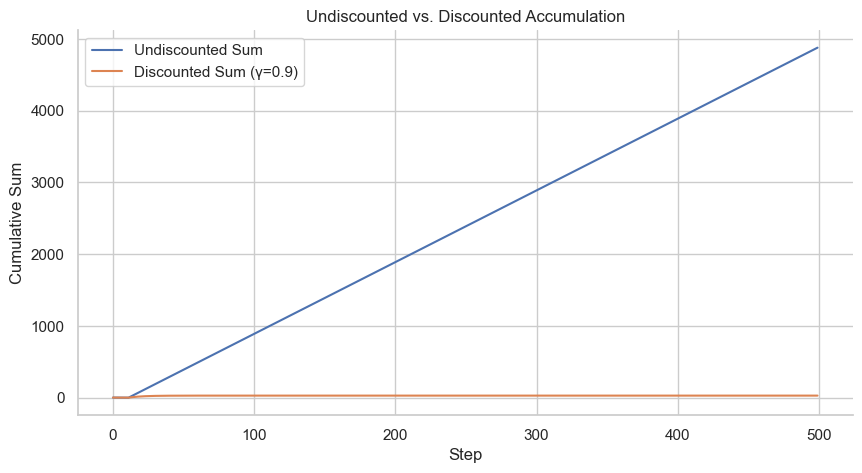

In [18]:
# --- Environment and Parameters ---
env = create_mystery_environment()
T = 500
seed = 123
# --- Run a single rollout (provided) ---
rewards = []
state, info = env.reset(seed=seed)
for step in range(T):
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)

# Convert rewards to a NumPy array for easier math
rewards = np.array(rewards)

# --- YOUR CODE HERE ---

# 1. Calculate the cumulative undiscounted sum.
undiscounted_sum = np.cumsum(rewards)

# 2. Create an array of discount factors for each timestep.
gamma = 0.9
discounts = np.array([gamma**t for t in range(T)])


# 3. Calculate the discounted rewards.
discounted_rewards = rewards * discounts

# 4. Calculate the cumulative discounted sum.
discounted_sum = np.cumsum(discounted_rewards)

# --- END YOUR CODE ---


# --- Visualize the results ---
plt.figure(figsize=(10, 5))
plt.plot(undiscounted_sum, label="Undiscounted Sum")
plt.plot(discounted_sum, label=f"Discounted Sum (γ={gamma})")
plt.title("Undiscounted vs. Discounted Accumulation")
plt.xlabel("Step")
plt.ylabel("Cumulative Sum")
plt.legend()
plt.grid(True)
plt.show()

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

The plot you just generated is the key to solving our first mystery. Analyze the two curves and answer the following questions:

1.  Describe the behavior of the **Undiscounted Sum** curve. Does it look like it will ever stop changing?
2.  Describe the behavior of the **Discounted Sum** curve. What is the key difference compared to the other curve?
3.  Based on this evidence, which of these two calculation methods produces a more stable and reliable metric for this environment? Why is this stability so important if we want to answer the client's question?

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: The Detective's Final Report
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

The evidence is conclusive: for this environment, discounting is the only way to get a stable, convergent value.

But now we must be precise. What does this number, and the curve that leads to it, actually represent? Our "Discounted Sum" plot was a useful tool for discovering convergence, but it doesn't show the true **Return** at each step.

There is one final clue we must investigate to close this case.

<br>

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click here to reveal the formal definition of Return</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

The **Discounted Return from time t**, denoted $G_t$, is formally defined as the sum of all *future* rewards, each discounted by how far it is in the future:

$G_t \equiv R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$

This is a **"sum-to-go"** — it's what the agent *expects to get* from this point onward.

Now compare this to our "Discounted Sum" plot. That plot showed a **"sum-that-happened"** — the total discounted value accumulated *from the start up to this point*. They are not the same thing!

To truly solve this case, you must now calculate and visualize the true Discounted Return, $G_t$.

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 3
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

This is your final task for this case. Given the sequence of `rewards` from our last experiment, you must write the code to calculate the true **Discounted Return $G_t$** for every step `t`.

Then, create a plot that compares two curves:
1.  The `discounted_sum` curve you created before (the "sum-that-happened").
2.  The new `true_Gt` curve you will calculate (the "sum-to-go").

This final plot will serve as the definitive piece of evidence in your report.

<details>
  <summary style="cursor: pointer; font-weight: bold;">Click here for a hint on calculating Gt!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

Calculating $G_t$ for every step efficiently can be tricky. A forward loop is complicated because you have to re-sum the entire rest of the array at each step.

A much cleverer approach is to iterate **backwards** from the end of the rewards list.

Think about it: the return at the very last step, $G_{T-1}$, is just the last reward, $R_T$. The return from the second-to-last step, $G_{T-2}$, is $R_{T-1} + \gamma G_{T-1}$. You can build up the entire array of Gt values this way.

**Pseudocode:**
<pre>
Initialize Gt_values as an array of zeros, same size as rewards
Set Gt_values[T-1] = rewards[T-1]
Loop t from T-2 down to 0:
  Gt_values[t] = rewards[t] + gamma * Gt_values[t+1]
</pre>

  </div>
</details>

  </div>
</div>

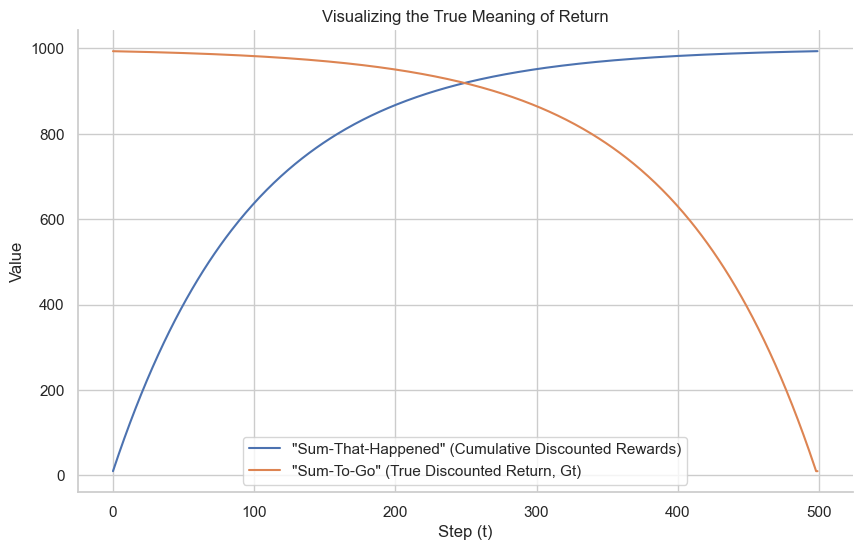

In [19]:
# --- We use the same data from the previous experiment for a direct comparison ---
# (This code is the same as before and is provided for you)
env = create_mystery_environment()
T = 500
seed = 123
gamma = 0.99

rewards = []
state, info = env.reset(seed=seed) 
for step in range(T):
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)
rewards = np.array(rewards)

# The "sum-that-happened" from our previous work (provided)
discounts = np.power(gamma, np.arange(T))
discounted_rewards = rewards * discounts
discounted_sum = np.cumsum(discounted_rewards)

# Calculate the true "sum-to-go" Discounted Return Gt for every step.
# Initialize an array to hold the Gt values.
true_Gt = np.zeros(T)

# --- YOUR CODE HERE ---
# Loop backwards from the second-to-last step to the first.
for t in range(T - 2, -1, -1):

    # Gt = R_t+1 + gamma * G_t+1
    # Note: our rewards array is 0-indexed (R_0 to R_T-1), so R_t+1 is rewards[t].
    # And G_t+1 is the value we just calculated in the previous iteration.
    true_Gt[t] = rewards[t + 1] + gamma * true_Gt[t + 1]


# Set the last Gt value. There are no future rewards, so G_T-1 = R_T-1
true_Gt[-1] = rewards[-1]


# --- END YOUR CODE ---


# --- Visualize the definitive results ---
plt.figure(figsize=(10, 6))
plt.plot(discounted_sum, label='"Sum-That-Happened" (Cumulative Discounted Rewards)')
plt.plot(true_Gt, label='"Sum-To-Go" (True Discounted Return, Gt)')
plt.title("Visualizing the True Meaning of Return")
plt.xlabel("Step (t)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: Case Closed
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Excellent work, detective. Your final plot is the conclusive piece of evidence. It perfectly illustrates the difference between a simple running total (the "sum-that-happened") and the true **Discounted Return $G_t$** (the "sum-to-go"). You have now mastered the tools to solve our first mystery.

Let's take a moment to review our investigation and see how our central question has become more precise with each new clue.

**The Evolving Question:**

1.  We started with the client's vague request:
    > *'What is the return of this environment?'*

2.  We quickly discovered that the agent's behavior was a missing variable, leading to a more specific question:
    > *'What is the return **of this environment** given a **Random Policy**?'*

3.  Finally, you proved that for this environment, we need a stable metric (discounting) and a specific target (the return from the start). Our question is now precise and actionable:
    > **'What is the Discounted Return of this environment from the start, $G_0$, given a Random Policy?'**

This is a well-defined question we can finally attempt to answer for our client. We have solved the mystery of *how* to measure the return.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: Verifying the Evidence
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

We have a precise question and a correct method to calculate the answer, $G_0$. In our last run, we got a single, concrete number for the Discounted Return from the start.

But a good detective never relies on a single piece of evidence. **Is this result repeatable?**

If we run the exact same experiment again, will we get the same trajectory and the same final value for $G_0$? There's only one way to find out. Let's run the simulation a few more times to verify our findings.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

To check for consistency, we will conduct a new experiment:

1.  Run the **entire simulation 5 separate times**.
2.  For each run, calculate the **true Discounted Return curve, $G_t$**.
3.  Plot all 5 of these $G_t$ curves on the **same graph**.

This will allow us to visually compare the results of multiple independent rollouts and see if the outcome is consistent.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 4
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Write the code to perform the multi-run experiment. The plotting code is provided for you.

Your task is to:
1.  Create a `for` loop that runs `N_RUNS` times.
2.  **Inside the loop:**
    - Run a full Monte Carlo rollout (reset the environment, loop for `T` steps, etc.).
    - Calculate the true Discounted Return curve (`true_Gt`) for that rollout's rewards.
    - Store the resulting `true_Gt` curve in the `all_Gt_curves` list.

  </div>
</div>

Running 5 simulations...
Simulations complete.


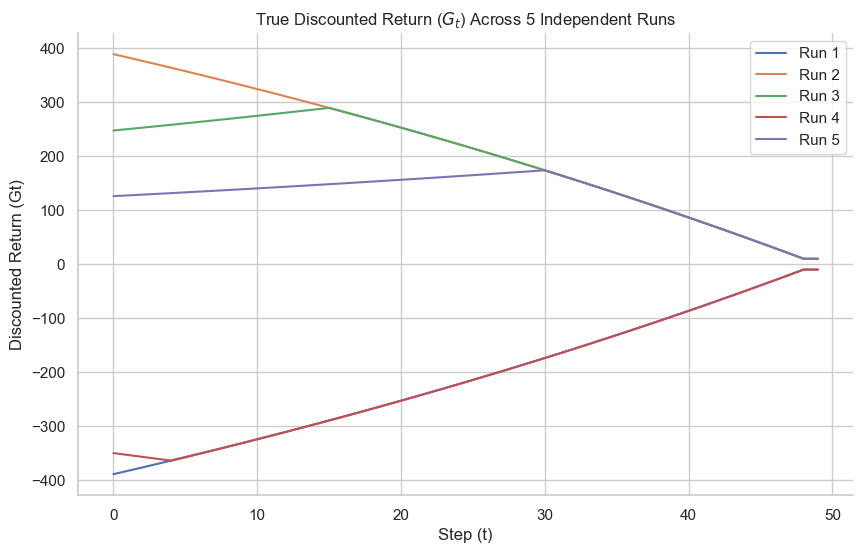

In [20]:
# --- Experiment Parameters ---
env = create_mystery_environment()
T = 50
gamma = 0.99
N_RUNS = 5 # The number of independent rollouts to run

# --- YOUR CODE HERE ---

# 1. Initialize a list to store the Gt curve from each run.
all_Gt_curves = []


# --- END YOUR CODE ---


print(f"Running {N_RUNS} simulations...")

# --- YOUR CODE HERE ---
# 2. Loop for N_RUNS.
for run in range(N_RUNS):
# --- END YOUR CODE ---

    # Run a full Monte Carlo rollout to collect rewards.
    rewards = []

    # --- YOUR CODE HERE ---
    # 3. Initialize the state using env.reset(). No seed, so each run is different
    env.reset()

    # --- END YOUR CODE ---

    for step in range(T):
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        rewards.append(reward)
    rewards = np.array(rewards)

    # Calculate the true Discounted Return Gt for this rollout.
    true_Gt = np.zeros(T)
    # Note: This is the same logic you implemented in the previous task.
    for t in reversed(range(T - 1)):
        true_Gt[t] = rewards[t] + gamma * true_Gt[t+1]
    true_Gt[T-1] = rewards[T-1]

    # --- YOUR CODE HERE ---
    # 4. Store the resulting Gt curve.
    all_Gt_curves.append(true_Gt)

    # --- END YOUR CODE ---

print("Simulations complete.")

# --- Visualize the results (provided) ---
plt.figure(figsize=(10, 6))

for i, Gt_curve in enumerate(all_Gt_curves):
    plt.plot(Gt_curve, label=f"Run {i+1}")

plt.title(f"True Discounted Return ($G_t$) Across {N_RUNS} Independent Runs")
plt.xlabel("Step (t)")
plt.ylabel("Discounted Return (Gt)")
plt.legend()
plt.grid(True)
plt.show()

<div style="width:100%;box-sizing;border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

This plot is a critical clue. Analyze the results from your 5 independent runs:

1.  Look at the starting point of each curve on the y-axis (at Step t=0). Are the initial values for $G_0$ the same for each run?
2.  Describe the overall shape and path of the 5 curves. Are they identical?
3.  What does this tell you about our refined question: "What is the Discounted Return from the start, $G_0$?" Is there a single, consistent answer?

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: The Big Picture
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Your analysis is correct. The value of $G_0$ is different every time. Our precise question, "What is the Discounted Return from the start?", does not have a single numerical answer. The result itself is a random variable!

This is a critical discovery. To give a complete answer to our client, we can't just provide the result of one or five runs. We need to understand the **distribution** of possible outcomes. What is a *typical* value for $G_0$? What are the best- and worst-case scenarios?

To see this pattern, we need a much larger sample of evidence.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

To understand the distribution of outcomes, we will perform a large-scale statistical experiment:

1.  Run the simulation **200 separate times**.
2.  For each run, we only need to calculate and store one number: the **Discounted Return from the start, $G_0$**.
3.  Plot a **histogram** of these 200 collected $G_0$ values.

This histogram will serve as our final piece of evidence for this case, revealing the shape and spread of the possible returns for our agent.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 5
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Write the code to perform the multi-run experiment and collect the values of $G_0$.

Your task is to:
1.  Create a `for` loop that runs `N_RUNS` times.
2.  **Inside the loop:**
    - Run a full Monte Carlo rollout.
    - Calculate the true Discounted Return curve (`true_Gt`) for that rollout.
    - Extract **only the first value** of that curve (`true_Gt[0]`), which is $G_0$.
    - Store this $G_0$ value in the `all_G0_values` list.

The plotting code to generate the histogram from your list is provided.

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click for a performance hint!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

The backward-loop method for calculating the full `true_Gt` array is great for understanding, but if you *only* need $G_0$, it's a bit inefficient.

A more direct way to calculate just $G_0$ is to use the original formula with your array of `rewards` and `discounts`:
<br>
`G0 = np.sum(rewards * discounts)`
<br>
This does the entire calculation in one fast, vectorized operation. For this task, either method is perfectly fine!

  </div>
</details>

  </div>
</div>

Running 200 simulations...
Simulations complete.

Mean G0: -342.84
Standard Deviation of G0: 836.25


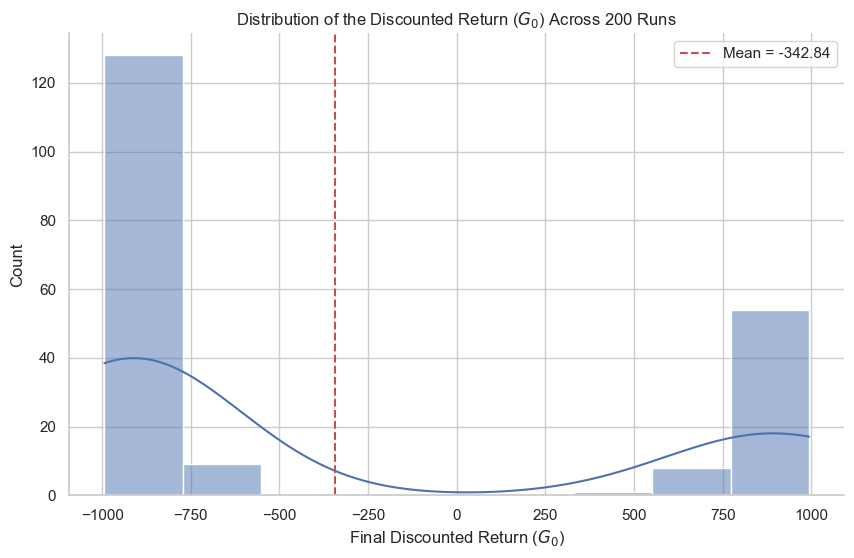

In [23]:
# --- Experiment Parameters ---
env = create_mystery_environment()
T = 500
gamma = 0.99
N_RUNS = 200 # A much larger number of runs for statistical analysis
# --- YOUR CODE HERE ---

# 1. Initialize a list to store the G0 value from each run.
all_G0_values = []

# --- END YOUR CODE ---

# Loop for N_RUNS.
print(f"Running {N_RUNS} simulations...")
for run in range(N_RUNS):
    # Run a full Monte Carlo rollout to collect rewards.
    rewards = []
    
    # No seed, so each run is different
    state, info = env.reset() 

    for step in range(T):
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        rewards.append(reward)
    rewards = np.array(rewards)

    
    discounts = np.power(gamma, np.arange(T))

    # --- YOUR CODE HERE ---
    # 2a. Calculate the Discounted Return from the start, G0.
    # (Using the efficient hint method)
    G0 = np.sum(rewards * discounts)

    # 2b. Store this G0 value.
    all_G0_values.append(G0)

    # --- END YOUR CODE ---

print("Simulations complete.")



# --- Visualize the results (provided) ---
plt.figure(figsize=(10, 6))
sns.histplot(all_G0_values, kde=True)
plt.title(f"Distribution of the Discounted Return ($G_0$) Across {N_RUNS} Runs")
plt.xlabel("Final Discounted Return ($G_0$)")
plt.ylabel("Count")
plt.grid(True)

# Also print some summary statistics
mean_G0 = np.mean(all_G0_values)
std_G0 = np.std(all_G0_values)
print(f"\nMean G0: {mean_G0:.2f}")
print(f"Standard Deviation of G0: {std_G0:.2f}")
plt.axvline(mean_G0, color='r', linestyle='--', label=f'Mean = {mean_G0:.2f}')
plt.legend()

plt.show()

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Analyze the histogram. This is the final piece of evidence for our current investigation, and the first clue for our next one.

We have a precise question ("What is the Discounted Return from the start?") and a correct calculation method. But the histogram proves that the answer is **not one number**—it is a whole distribution of possible outcomes.

A rookie detective might just calculate the mean and report that as the final answer. But would you be satisfied with that?

The plot shows that the return can sometimes be much better, and sometimes catastrophically worse. A simple average hides the **risk and unpredictability** of the system. More importantly, the average return is terrible! The client's ultimate goal is to **improve** it. How can we possibly suggest an improvement if we don't know what's causing the bad outcomes?

Our investigation cannot end here. To truly answer the client's needs, we must first understand the *causes* of this variance.

**What are the hidden mechanisms inside our "black box" that are causing the result for $G_0$ to be different every single time?**

This is our next case: **The Mystery of the Unpredictable Return.**

  </div>
</div>

# Case 2: The Mystery of the Unpredictable Return

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Case File: The Prime Suspect
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

At the end of our last investigation, we were left with a perplexing clue: the histogram of the Discounted Return, $G_0$, showed a wide and unpredictable distribution. Our goal in this new case is to identify all the hidden sources of randomness that are causing this variance.

A good detective starts by interrogating the most obvious suspect. 

**What do you think it could be?**

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click here when you are ready.</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

In our case, that is the agent's own behavior.

**The Prime Suspect: The `Random Policy`**

The agent is currently making different choices in every run because its policy is to act randomly. This is almost certainly a major cause of the unpredictable outcomes.

Our first step is to isolate this variable. We will replace our unpredictable `Random Policy` with a completely predictable **Deterministic Policy**. By controlling for the agent's actions, we can determine how much of the variance is the agent's fault, and how much is caused by the environment itself.

</details>
  </div>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Before we write any code, let's think like a detective designing an experiment. We need to create a new policy that is **perfectly predictable** to eliminate the agent's randomness.

But what's the *best* way to do that? Our ideal "probe" policy should have three properties:

1.  **Deterministic:** It must produce the exact same sequence of actions every time we use it.
2.  **Simple:** It should be easy to implement and understand.
3.  **Good Coverage:** Ideally, it should explore a large part of the environment to gather as much evidence as possible.

How could you design a policy that meets all three criteria?

<br>

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click here for a hint and the official solution</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

This is a surprisingly tricky design problem! An "Always Right" policy is simple and deterministic but has terrible coverage. A complex, hardcoded pattern (like a figure-eight) might have good coverage but isn't simple to implement.

What if we could have the best of both worlds? What if we could use a **random** policy for its great coverage, but somehow make it **perfectly reproducible**?

This is a standard technique in computational science. We can use a **local, seeded Random Number Generator (RNG)**. An RNG initiated with a specific seed (e.g., `seed=42`) will always produce the exact same sequence of "random" numbers.

This gives us our perfect tool: a **Reproducible Random Policy**.

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 1
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Now, let's build our new forensic tool. Implement the `ReproducibleRandomPolicy` class in the code cell below.

**Requirements:**

1.  The `__init__` method must accept a `seed` and an `action_space` from the environment.
2.  Inside `__init__`, you must create a **local, seeded Random Number Generator (RNG)** instance.
3.  The `choose_action` method should use this local RNG to select a random action. It should not use the global `np.random` and return an `action`.

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click for a hint on implementation!</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

- To create the local RNG, use `np.random.default_rng(seed)`.
- The `action_space` object has a useful property `n` which tells you the number of possible actions (e.g., 4 for FrozenLake).
- To choose a random action index from `0` to `n-1`, you can use your RNG's `integers` method: `self.rng.integers(low=0, high=self.action_space.n)`.

  </div>
</details>

  </div>
</div>

In [ ]:
class ReproducibleRandomPolicy:
    """
    A policy that generates a deterministic sequence of "random" actions
    based on a provided seed. This is used to control for the agent's
    randomness while still allowing for broad exploration.
    """
    def __init__(self, action_space, seed):
        # --- YOUR CODE HERE ---
        
        # 1. Store the action space and seed
        self.action_space = 
        self.seed = 
        
        # 2. Create a local, seeded Random Number Generator
        self.rng = 

        # --- END YOUR CODE ---
        
    def choose_action(self):
        # --- YOUR CODE HERE ---

        # 3. Use the local RNG to choose a random action index
        
        
        # --- END YOUR CODE ---

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Let's verify that our `ReproducibleRandomPolicy` works as expected. A proper forensic tool must be reliable.

We will conduct a simple test:
1.  Run a loop 5 times.
2.  In each iteration, we will create a **brand new instance** of our policy, but always give it the **same seed**.
3.  We will ask each new policy instance to generate a sequence of 10 actions.
4.  Finally, we will print all 5 sequences.

If our tool is working correctly, every single action sequence should be a perfect copy of the others, proving that the seed controls the "randomness."

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 2
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Write the code to perform the verification test.

**Your Task:**
1.  Create an outer `for` loop that runs 5 times.
2.  Inside the loop, create a **new instance** of your `ReproducibleRandomPolicy`.
3.  Create an inner `for` loop that runs 10 times to generate a sequence of actions from your new policy instance.
4.  Print the resulting sequence for each of the 5 runs.

  </div>
</div>

In [ ]:
# --- Verification Parameters ---
# We need a dummy environment just to get its action_space
dummy_env = create_mystery_environment()
action_space = dummy_env.action_space
SEED_FOR_POLICY = 123 # The seed for our reproducible policy
N_SEQUENCES = 5
SEQUENCE_LENGTH = 10


print(f"Generating {N_SEQUENCES} action sequences using the same seed ({SEED_FOR_POLICY})...")
# --- YOUR CODE HERE ---
# 1. Loop N_SEQUENCES times

for 
    
    # 2. Create a new policy instance WITH THE SAME SEED
    
    
    # 3. Generate a sequence of actions and store it in action_sequence
    action_sequence = []
    for _ in range(SEQUENCE_LENGTH):
        action = policy.choose_action()
        action_sequence.append(action)
        
    # Print the sequence
    print(f"Run {i+1}: {np.array(action_sequence)}")

# --- END YOUR CODE ---

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: Verification Complete
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

The evidence is clear: every run produced the exact same sequence of actions.

You have successfully built and verified a "robot" agent that will follow the exact same script of seemingly random actions every time. This is the perfect tool for our investigation.

Now that we can control for the agent's behavior, we can finally conduct our main experiment to see how much randomness is coming from the environment itself.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Now that our forensic tool is verified, let's conduct the main experiment. We will repeat the histogram experiment from the end of Section 1, but with one crucial change.

**The Plan:**

1.  Run the simulation **200 separate times**.
2.  In each run, use a new instance of our `ReproducibleRandomPolicy` (with the same seed each time) to ensure the agent's action sequence is identical.
3.  Calculate and store the **Discounted Return from the start, $G_0$**, for each run.
4.  Plot a **histogram** of these 200 collected $G_0$ values.

This experiment will finally tell us: if the agent's behavior is perfectly predictable, will the final return also be predictable?

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 3
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

The main simulation loop is provided for you. Your task is to make two crucial changes to the experiment to control for the agent's randomness.

1.  **Inside the `for` loop**, at the beginning of each run, create a **new instance** of your `ReproducibleRandomPolicy`. It is critical to create a fresh instance for each run to reset the policy's internal random number generator, ensuring the action sequence is identical every time.
2.  **Inside the loop**, modify the line that chooses an action to use your new, deterministic policy instance instead of the random `env.action_space.sample()`.

This will ensure our agent is a reproducible "robot," following the exact same script of actions in every single one of the 200 runs.

  </div>
</div>

In [ ]:
# --- Experiment Parameters ---
env = create_mystery_environment()
T = 500
gamma = 0.99
N_RUNS = 200
POLICY_SEED = 42 # The seed for our agent's brain

# The rest of the simulation loop is provided for you
all_G0_values = []
print(f"Running {N_RUNS} simulations with a deterministic policy...")
for run in range(N_RUNS):

    # --- YOUR CODE HERE ---
    # 1. Create a new policy instance.
    # This resets the RNG to the start of its sequence for every run.
    policy = 

    # --- END YOUR CODE ---

    rewards = []
    state, info = env.reset() 
    for step in range(T):
        # --- YOUR CODE HERE ---
        
        # 2. Use your new policy to choose the action.
        action = 
        
        # --- END YOUR CODE ---
        
        state, reward, terminated, truncated, info = env.step(action)
        rewards.append(reward)
    rewards = np.array(rewards)

    discounts = np.power(gamma, np.arange(T))
    G0 = np.sum(rewards * discounts)
    all_G0_values.append(G0)

print("Simulations complete.")

# --- Visualize the results (provided) ---
plt.figure(figsize=(10, 6))
sns.histplot(all_G0_values, kde=True, bins=30)
plt.title(f"Distribution of $G_0$ with a Deterministic Policy")
plt.xlabel("Final Discounted Return ($G_0$)")
plt.ylabel("Count")
plt.grid(True)

# Also print some summary statistics
mean_G0 = np.mean(all_G0_values)
std_G0 = np.std(all_G0_values)
print(f"\nMean G0: {mean_G0:.2f}")
print(f"Standard Deviation of G0: {std_G0:.2f}")
plt.axvline(mean_G0, color='r', linestyle='--', label=f'Mean = {mean_G0:.2f}')
plt.legend()

plt.show()


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Analyze the new histogram and the summary statistics you just generated.

1.  Compare the **Standard Deviation** of this histogram to the one from the end of Section 1 (which used the truly `Random Policy`). Has it gone down?
2.  We have completely eliminated randomness from the agent's decisions. Is the final return $G_0$ now a single, predictable number, or is there still significant variance?
3.  What does this prove about our prime suspect? Is the `Random Policy` the *only* source of randomness, or must there be other sources hidden in the environment itself?

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: Looking for More Clues
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">


Your deduction is correct. Even with a predictable agent, the outcome is still unpredictable. The environment itself must be a source of randomness.

Now, think like a detective. Our high-level analysis of the histogram has told us *that* there is a problem, but not *what* is causing it. To find the specific cause, we need to "zoom in" and look at the raw, low-level evidence from individual runs.

What is the most fundamental, step-by-step data we could record during a simulation to see exactly what the agent did and what the environment did in response?

<br>

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click to reveal the forensic tool</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

The most fundamental piece of evidence is the **Trajectory**.

A trajectory is the detailed, moment-by-moment log of an episode. For each step, it records the essential interaction between the agent and the environment:

- The `state` the agent was in.
- The `action` the agent took.
- The `reward` the environment gave back.
- The `next_state` the agent ended up in.

By printing and comparing the trajectories of a few different runs, we can look for differences that will reveal the environment's hidden mechanisms. This process is our next forensic tool: **Trajectory Analysis**.

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align:items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Let's use our new tool to hunt for clues. We will conduct a small-scale experiment designed for careful observation.

**The Plan:**

1.  Run the simulation **6 separate times**.
2.  In each run, we will use our `ReproducibleRandomPolicy` to ensure the agent's action script is identical.
3.  For each run, we will record and print the **first 5 transitions**.

This will create a comparison table, allowing us to see if we can spot any differences in how the environment behaves from run to run.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 4
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

The data collection loop is provided for you below. Your task is to complete the single line of code that captures the evidence.

At each step, we have the agent's current `state`, the `action` it takes, the `reward` it receives, and the `next_state` it lands in. This `(state, action, reward, next_state)` tuple is the **transition**.

**Your Task:**
- Inside the loop, define the `transition` tuple using the variables provided. This captured evidence will then be automatically formatted and printed for your analysis.

  </div>
</div>

In [ ]:
# --- Experiment Parameters ---
env = create_mystery_environment()
policy_class = ReproducibleRandomPolicy
policy_seed = 42
n_runs = 6
n_steps = 5


# --- Data Collection and Formatting ---
# We'll build a list of formatted strings to print at the end
output_lines = []
print(f"Analyzing trajectories from {n_runs} independent runs...")

for run in range(n_runs):
    policy = policy_class(env.action_space, seed=policy_seed)
    state, info = env.reset() 
    
    # This string will hold the formatted output for this single run
    run_output_string = ""
    
    for step in range(n_steps):
        action = policy.choose_action()
        next_state, reward, terminated, truncated, info = env.step(action)
        
        # --- YOUR CODE HERE ---

        # 1. Define the transition tuple for this step
        transition =
        
        # --- END YOUR CODE ---
        
        # This part formats the transition into the string for printing (provided)
        s, a, r, ns = transition
        run_output_string += f"| {s:2d} | {a:d} | {r:6.2f} "
        
        # Update the state for the next loop iteration
        state = next_state
    
    # Add the final state to the end of the row
    # run_output_string += f"| S_{n_steps}={state:2d}"
    output_lines.append(run_output_string + f"| {state:2d}")


# --- Print the Final Comparison Table (provided) ---
header = "         "
for t in range(n_steps):
    header += f"S_{t}  A_{t}   R_{t+1}    "
print(header + f"S_{t+1}")
print("=" * (n_steps * 21))

for i, line in enumerate(output_lines):
    print(f"Run {i+1:2}: {line}")

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Analyze the comparison table you just generated. This is a crucial piece of forensic evidence.

The agent's policy was identical in every run. Based on the data in the table, can you spot any differences in how the **environment** behaved from run to run? What is the most obvious source of environmental randomness you can identify from this evidence?

<br>

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click for a guided analysis</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

1.  First, confirm your control. Look at the `A_t` columns (the actions). Is the sequence of actions the same for every single run?
2.  Now, look for the anomaly. Compare the `S_0` column (the starting state) across all the runs. Is it the same every time?
3.  What does this prove?

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: First Environmental Suspect Identified
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Your analysis of the trajectory logs is correct. You have successfully identified the first source of environmental randomness.

<br>

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click to reveal the suspect's identity</summary>
  <div style-padding-top: 10px; margin-top: 10px;">

The evidence is undeniable: the agent is **not starting in the same state** in every run.

Even though our policy is deterministic, the different starting positions lead to different trajectories, which in turn lead to different final returns. You have proven that the **Random Start State** is a major culprit behind the variance of $G_0$ we saw in the histogram.

A good detective's next step is always to isolate the variable they've just identified. We must now conduct an experiment where we control for the start state to see what other sources of randomness might still be at large.

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: Establishing a Baseline
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Excellent work. Let's recap our investigation. We have proven that the unpredictability in our experiment comes from two distinct places:

1. **The Policy:** 
2. **The Environment** 

We have already controlled for the first source by creating our `ReproducibleRandomPolicy`. However, you just proved that the environment is *also* a source of randomness when you identified the **Random Start State**.

Before we can scientifically measure the impact of this suspect, we need a stable, **fully reproducible baseline**. This requires controlling *all* sources of randomness in the experiment, including the environment's.

To make our future investigations more efficient and rigorous, we will now refactor our histogram code into a reusable function. This will become our standardized tool for creating a baseline and testing our hypotheses.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align:items:center;gap:8px;">
    🛠️ Task 5
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Let's build our standardized testing tool. The skeleton of a function called `run_histogram_experiment` is provided in the next cell. The function is designed to be a reusable "forensic lab" for running controlled, reproducible experiments.

Most of the code is already filled in for you. Your task is to complete the logic inside the `for` loop that correctly prepares each run.

**Your Task:**
1.  **Instantiate a new policy object.** This is a critical step to reset the policy's internal state and ensure its action sequence is the same for every run.
2.  **Reset the environment.** Use the `env_seed` variable to make sure the environment's starting state and dynamics are reproducible. (`env.reset(seed=env_seed)`)
3.  **Increment the `env_seed` variable.** This ensures that while the entire experiment is reproducible, each individual run within it has a unique instantiation of the environment.
 


  </div>
</div>

In [ ]:
def run_histogram_experiment(
    # --- Experiment Configuration ---
    env,
    policy_class,
    policy_seed=42,
    env_seed=123,
    n_runs=200,
    n_steps=500,
    gamma=0.99
):
    """
    Runs a fully reproducible multi-run experiment on a given environment
    with the same policy on every run and plots a histogram of the G0 values.
    """
    all_G0_values = []

    print(f"Running {n_runs} simulations with a deterministic policy...")
    for run in range(n_runs):
        rewards = []

        # --- YOUR CODE HERE ---

        # 1. Instantiate a new policy object to reset its internal RNG state.
        policy = 

        # 2. Reset the environment with the current seed.
        

        # 3. Increment the seed for the next run.
        
        
        # --- END YOUR CODE ---

        for step in range(n_steps):
            
            action = policy.choose_action()
            state, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
        rewards = np.array(rewards)

        discounts = np.power(gamma, np.arange(n_steps))
        G0 = np.sum(rewards * discounts)
        all_G0_values.append(G0)

    print("Simulations complete.")

    # --- Visualize the results (UPGRADED LOGIC) ---
    plt.figure(figsize=(10, 6))
    
    mean_G0 = np.mean(all_G0_values)
    std_G0 = np.std(all_G0_values)
    
    # THE FIX: Check if the data is deterministic before plotting
    if np.isclose(std_G0, 0):
        # If there's no variance, just draw a single line (a bar chart is also fine)
        # and don't use KDE.
        plt.bar(x=mean_G0, height=n_runs, width=0.2, label=f'Deterministic Outcome = {mean_G0:.2f}')
        plt.title(f"Deterministic Result for $G_0$ Across {n_runs} Runs")
        plt.xlim(mean_G0 - 1, mean_G0 + 1)
        plt.axvline(mean_G0, color='r', linestyle='--', label=f'Mean = {mean_G0:.2f}')
        plt.ylim(0, n_runs * 1.1) 
    else:
        # If there is variance, use the histogram with the density curve.
        sns.histplot(all_G0_values, kde=True, bins=30)
        plt.title(f"Distribution of $G_0$ Across {n_runs} Runs")
        plt.axvline(mean_G0, color='r', linestyle='--', label=f'Mean = {mean_G0:.2f}')

    plt.xlabel("Final Discounted Return ($G_0$)")
    plt.ylabel("Count")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    print(f"\nMean G0: {mean_G0:.2f}")
    print(f"Standard Deviation of G0: {std_G0:.4f}")

    # Return the statistics for later comparison
    return mean_G0, std_G0

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Now that you have a standardized and fully reproducible testing function, it's time to create our official baseline.

**The Plan:**

1.  Create an instance of the "black box" environment..
2.  Call your `run_histogram_experiment` function to run a full, reproducible experiment on this environment.

The resulting histogram and its **Standard Deviation** will serve as our definitive baseline. All future experiments, where we isolate variables, will be compared against this measurement to determine their impact.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 6
  </div> 

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Write the code to generate our official, reproducible baseline.

**Your Task:**
1.  Create the `baseline_env` by calling `create_mystery_environment()`.
2.  Create `policy_seed=42` and `env_seed=123` for reproducibility.
3.  Store the returned `std_G0` in `baseline_std` and `mean_G0` in `baseline_mean` for future comparison.
4.  Call your `run_histogram_experiment()` function, passing in the environment and the `ReproducibleRandomPolicy` class.

  </div>
</div>

In [ ]:
# --- YOUR CODE HERE ---

# 1. Create the mistery environment for our baseline experiment.


# 2. Create the policy and env seed.


# 3. Run the experiment to generate our official, reproducible baseline.
print("--- Generating Reproducible Baseline ---")


# --- END YOUR CODE ---

print(f"\nOfficial Baseline Standard Deviation: {baseline_std:.4f}")
print(f"\nOfficial Baseline Mean: {baseline_mean:.4f}")

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align:items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Now that we have our official baseline, we can begin to isolate our suspects. The first environmental culprit we identified was the **Random Start State**. Let's conduct a controlled experiment to measure its impact.

**The Plan:**

1.  We will request a special version of the environment from the "client's lab" that is guaranteed to **always start in the same state**. We can do this by using our `create_mystery_environment` function with the `has_random_start=False` flag.
2.  Using this new, "fixed-start" environment, we will run our standardized histogram experiment.
3.  We will then compare the **Standard Deviation** of this new experiment to our `baseline_std`.

By comparing the two standard deviations, we can **estimate the impact** of the random start state. This will tell us if it was a major or minor source of the overall unpredictability.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align:items:center;gap:8px;">
    🛠️ Task 7
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Write the code to perform the controlled experiment.

**Your Task:**
1.  Create a new "fixed-start" environment by calling `create_mystery_environment` with the `has_random_start` flag set to `False`.
2.  Call your `run_histogram_experiment()` function to run a full, reproducible experiment on this new environment.
3.  Store the returned standard deviation in a new variable called `fixed_start_std`.
4.  Print a comparison between the `baseline_std` and the new `fixed_start_std` to see the difference.

  </div>
</div>

In [ ]:
# --- YOUR CODE HERE ---

# 1. Create the "fixed-start" environment.
fixed_start_env = 

# 2. Run the experiment on this new environment.
print("--- Running Experiment with Fixed Start State ---")
_, fixed_start_std = 

# --- END YOUR CODE ---


# --- Compare the results (provided) ---
print("\n--- Variance Investigation Results ---")
print(f"Baseline Standard Deviation:      {baseline_std:.4f}")
print(f"Fixed-Start Standard Deviation:   {fixed_start_std:.4f}")

variance_reduction = (1 - (fixed_start_std / baseline_std)) * 100
print(f"\nBy fixing the start state, we reduced the standard deviation by ~{variance_reduction:.2f}%.")


<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Analyze the results of your latest experiment.

1.  By fixing the start state, did the standard deviation of $G_0$ decrease significantly compared to the baseline? What does this confirm about the `Random Start State` as a source of unpredictability?
2.  Did the standard deviation go all the way to zero?
3.  Based on this evidence, what can you conclude? Have we found all the sources of randomness, or are there still more suspects at large, hidden in the environment's dynamics?

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: Another Suspect at Large
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Your analysis is correct. You have successfully isolated and measured the impact of the `Random Start State`, but the case is far from closed. The remaining variance proves that there is at least one more source of unpredictability hidden in the environment's dynamics.

The numerical trajectory logs were great for spotting the first clue, but the next suspect is more subtle. We need a more powerful tool to see what's happening moment-to-moment. Any idea?

<br>

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click to reveal the next forensic tool</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

Our next tool is **Visual Rendering**.

Instead of reading logs of numbers, we will "watch a replay" of the agent's actions on the grid. We will use a special text-based rendering mode (`ansi`) that works directly inside this notebook, allowing us to see the agent's position at every step.


  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Let's use our new visual tool to see if we can catch the next suspect in the act. To get the clearest possible evidence, we need to create the most controlled experiment yet.

**The Plan:**

1.  We will run a **single, short simulation** (`15` steps) to make observation easy.
2.  We will use our fully controlled setup from the last experiment: a **fixed start state** and our **`ReproducibleRandomPolicy`**.
3.  At each step of the simulation, we will do two things:
    - **Print the action** commanded by the policy.
    - **Render a "frame"** of the environment grid showing the result of that action.

This will create a step-by-step replay that might give us more insgight in what is really happening in our simulation.

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 8
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

The code to run the replay simulation is provided below. It includes a helper function to clear the output between frames to create an animation effect.

There are no new concepts to implement in this task. Your only job is to **run the cell and carefully observe the output**.

- **Read the printed command** from the policy at each step.
- **Watch the colored square** (representing the agent) on the grid.

  </div>
</div>

In [ ]:
import time
from IPython.display import display, clear_output

# --- Experiment Parameters ---
# We use a 'fixed-start' environment for a clean, repeatable replay
env = create_mystery_environment(has_random_start=False, render_mode='ansi')
policy = ReproducibleRandomPolicy(env.action_space, seed=42)
N_STEPS = 15
ACTION_MAP = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}


# --- Run the Simulation and Render ---
state, info = env.reset(seed=123) # Use a specific seed for a specific replay

for t in range(N_STEPS):
    # Get the frame before the action is taken
    # In 'ansi' mode, render() returns a string
    frame = env.render()
    
    # Get the action from our deterministic policy
    action = policy.choose_action()
    
    # --- Display the output ---
    clear_output(wait=True) # Clears the previous frame
    print(f"--- Step {t} ---")
    print(f"Policy's Command: Action {action} ({ACTION_MAP[action]})")
    print(frame) # Print the current state of the grid
    time.sleep(1.5) # Pause to make it watchable
    
    # Take the step in the environment
    state, reward, terminated, truncated, info = env.step(action)
    
    if terminated or truncated:
        print("\nEpisode finished!")
        break

# Show the final frame
clear_output(wait=True)
print(f"--- Final State (after {t+1} steps) ---")
print(env.render())

<div style="width:100%;box-sizing;border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Carefully analyze the replay and the printed commands from the previous cell.

Do you notice any inconsistencies in the environment's behavior?

<br>

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click for a guided analysis</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

Focus on the agent's position (the colored square) in each frame. Does the agent's movement on the grid *always* match the direction commanded by the policy?

What does it mean if the agent's intentions and the environment's response do not always match?

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: The Ghost in the Machine
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

<details>
  <summary style="cursor: pointer; font-weight: bold; ">Click to reveal the suspect's identity</summary>
  <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">

You've found the smoking gun. The replay shows moments where the policy commands one action, but the environment moves the agent in a completely different direction.

Even when the agent and the start state are fully controlled, the environment itself can override the agent's intentions. This "slippery ice" is the final source of randomness we have been looking for.

In formal terms, you have discovered that this environment has **Stochastic Transitions**. The outcome of an action, given a state, is not guaranteed; it is a probability distribution over possible next states. This is the "ghost in the machine" that was causing the last bit of variance in our histograms.

  </div>
</details>

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #FF7A59;border-radius:10px;overflow:hidden;">
  <div style="background:#FF7A59;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🔬 Experiment
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

You have found one more source of randomness: **Stochastic Transitions**.

Let's run our histogram experiment one more time, but now we will control for all three suspects we have identified.

**The Plan:**

1.  Create a "clean room" environment where **all known sources of environmental randomness are disabled** (`has_random_start=False` and `is_slippery=False`).
2.  Run our standardized histogram experiment on this controlled environment, using our `ReproducibleRandomPolicy`.


  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #2DB380;border-radius:10px;overflow:hidden;">

  <div style="background:#2DB380;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    🛠️ Task 9
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Write the code to perform the fully controlled experiment.

**Your Task:**
1.  Create a "clean room" environment by calling `create_mystery_environment` with both `has_random_start` and `is_slippery` set to `False`.
2.  Call your `run_histogram_experiment()` function to run a full, reproducible experiment on this new environment.
3.  After the plot is generated, reflect on the result. What does the shape of this new histogram tell you?

  </div>
</div>

In [ ]:
# --- YOUR CODE HERE ---

# 1. Create the fully controlled "clean room" environment.
clean_env = 

# 2. Run the experiment on this new environment.
print("--- Running Experiment in a Fully Controlled Environment ---")


# --- END YOUR CODE ---

In [ ]:
# --- YOUR CODE HERE ---

# 1. Create the fully controlled "clean room" environment.
clean_env = 

# 2. Run the experiment on this new environment.
print("--- Running Experiment in a Fully Controlled Environment ---")


# --- END YOUR CODE ---

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #7A52CC;border-radius:10px;overflow:hidden;">

  <div style="background:#7A52CC;color:white;padding:10px 14px;font-weight:700;display:flex;align:items:center;gap:8px;">
    ❓ Question
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Analyze the final plot you just generated. This is the last piece of evidence in this case.

1.  Describe the shape of the histogram. How does it differ from all the previous histograms you have created?
2.  The Standard Deviation is now zero (or extremely close to it). What does this tell you about the predictability of the outcome in this "clean room" environment?
3.  Based on this evidence, what can you conclude? Have you successfully identified and controlled all the sources of randomness that were causing the **return to be unpredictable**?

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align-items:center;gap:8px;">
    📘 Explanation: The Grand Reveal
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">

Congratulations, detective. You have solved **The Mystery of the Unpredictable Return**. You have successfully dismantled the "black box" and found all of its moving parts.

Now, let's look at the official blueprints. In reinforcement learning, every clue you uncovered has a formal name.

*   The "locations" on the grid form the **State Space ($S$)**.
*   The available moves form the **Action Space ($A$)**.
*   The "slippery ice" that caused unpredictable movements is the **Transition Function, $P(s'|s,a)$**.
*   The "cost of living" and goal/hole values form the **Reward Function, $R(s,a)$**.
*   The "random starts" you found are defined by the **Start-State Distribution, $\delta_0$**.
*   The "patience factor" you discovered is the **Discount Factor, $\gamma$**.

Together, the tuple `(S, A, P, R, γ)` defines the **Markov Decision Process (MDP)**, and with the initial state distribution `δ₀` it fully specifies our environment.

**The Evolving Question:**

Your understanding has also allowed our central question to become fully precise.
1.  We started with: 
    > *'What is the return of this environment?'*
2.  We refined it to: 
    > *'What is the Discounted Return of this environment from the start, $G_0$, for a Random Policy?'*
3.  Now, we can state it with full formality:
    > **"Given the MDP `M = (S, A, P, R, γ)` with `δ₀`, what is the *Expected* Discounted Return from the start, $\mathbb{E}_{\pi}[G_0]$, for policy $\pi$?"**

This is a perfectly defined question. But is answering it for a *random* policy the end of our work? Is that the best we can do for our client? 

  </div>
</div>

<div style="width:100%;box-sizing:border-box;margin:14px 0;border:1px solid #5B8DEF;border-radius:10px;overflow:hidden;">

  <div style="background:#5B8DEF;color:white;padding:10px 14px;font-weight:700;display:flex;align:items:center;gap:8px;">
    📘 Explanation: Case Closed
  </div>

  <div style="padding:14px 16px;line-height:1.55;word-wrap-break-word;overflow-wrap-break-word;">


You have successfully solved **Case #2: The Mystery of the Unpredictable Return**.

However, in achieving perfect predictability, you have also proven that the `Random Policy` is predictably terrible. This brings us to the ultimate goal of reinforcement learning: it is not enough to simply *predict* the return of a given policy. We must find ways to **improve** it.

But how can we build a better policy if we don't have a complete "map of value" for our environment? 

This brings us to our next case: **The Map of Value.**

**That, however, is a case for our next tutorial...**

  </div>
</div>